# Predicción de mora temprana en microcréditos MYPE
**Notebook 03 · Separación, pipeline, modelos preliminares y evaluación**

Requiere haber ejecutado el notebook 02.

In [2]:
%pip install --ignore-installed --no-deps matplotlib==3.10.9

  Using cached matplotlib-3.10.9-cp310-cp310-win_amd64.whl.metadata (52 kB)
Using cached matplotlib-3.10.9-cp310-cp310-win_amd64.whl (8.2 MB)
Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
    roc_curve, roc_auc_score,
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
sys.path.append("..")

# df = pd.read_csv("../data/processed/creditos_limpio.csv")

In [4]:
# ⚠️ TEMPORAL: limpieza mínima para avanzar mientras el notebook 02 está en proceso.
# Reemplazar por: df = pd.read_csv("../data/processed/creditos_limpio.csv")
df = pd.read_csv("../data/raw/creditos_mype.csv")
df = df.drop_duplicates()

for col in ["fecha_solicitud", "fecha_desembolso"]:
    df[col] = pd.to_datetime(df[col], format="mixed", dayfirst=True)

df["ingreso_mensual_declarado"] = pd.to_numeric(
    df["ingreso_mensual_declarado"].astype(str)
      .str.replace("S/", "", regex=False)
      .str.replace(",", "", regex=False)
      .str.strip(),
    errors="coerce",
)

df = df.drop(columns=["num_gestiones_cobranza", "estado_credito_corte"])

## 5. Separación de los datos

### 5.1 Variables del modelo

In [5]:
# Excluir de X: identificadores, variables con fuga y la propia variable objetivo.

TARGET = "mora_30d_6m"
COLS_ID = ["id_credito", "id_cliente"]
COLS_FECHA = ["fecha_solicitud", "fecha_desembolso"]
COLS_EXCLUIR = COLS_ID + COLS_FECHA + [TARGET]

y = df["mora_30d_6m"]
X = df.drop(columns=COLS_EXCLUIR)


**Variables excluidas y motivo:**

- Se excluyeron las variables fechas, pues se aporte sirve mas para otros modelos que dependen de la estacionalidad, en el caso del modelo clasificador usado, dependera de la  variable mora_30d_6m, como aprendizaje supervisado.
- Se excluyo mora_30d_6m de X pues es la variable objetivo
- Se excluyeron los ID, pues no aportan informacion importante para el modelo. Su importancia puede ir mas por el analisis EDA, pero no para el entrenamiento, ya que no poseen algun comportamiento importante.

### 5.2 Estrategia de separación

**Estrategia y proporciones:**
Se evito usar aleatorizacion estratificada, pues se mezclarian creditos de distintos periodos en el train y test. Si esto sucede, el modelo podria entrenarse con creditos posteriores y evaluarse con creditos anteriores, lo cual en la practica es imposible, pues al momento de evaluar una solicitud solo se conoce informacion del pasado. Por ello, las metricas saldrian mas optimistas de lo que el modelo rendiria en realidad.

Por eso se opto por un analisis del tiempo, se hizo el siguiente analisis de los Qs.

In [6]:
conteo = df.groupby(df["fecha_desembolso"].dt.to_period("Q")).size()
resumen = pd.DataFrame({
    "creditos": conteo,
    "proporcion_acumulada": conteo.cumsum() / conteo.sum(),
    "tasa_mora": df.groupby(df["fecha_desembolso"].dt.to_period("Q"))["mora_30d_6m"].mean(),
})
resumen

,creditos,proporcion_acumulada,tasa_mora
fecha_desembolso,,,
2022Q1,752,0.048847,0.117021
2022Q2,1000,0.113803,0.099000
2022Q3,1126,0.186944,0.099467
2022Q4,1210,0.265541,0.116529
2023Q1,1235,0.345762,0.124696
2023Q2,1306,0.430594,0.138591
2023Q3,1367,0.519389,0.145574
2023Q4,1405,0.610653,0.106762
2024Q1,1435,0.703865,0.101742


Segun los resultados se opto por lo siguiente: train hasta 2024Q1 (70%), validation 2024Q2 y 2024Q3 (20%) y test 2024Q4 (10%). Asi se imita el uso real del modelo, que siempre evaluara creditos posteriores a los que conoce.

In [7]:
CORTE_VAL = "2024-04-01"    # validación: 2024Q2 – 2024Q3
CORTE_TEST = "2024-10-01"   # test: 2024Q4

fechas = df["fecha_desembolso"] # Fechas para realizar corte

masc_train = fechas < CORTE_VAL
masc_val = (fechas >= CORTE_VAL) & (fechas < CORTE_TEST)
masc_test = fechas >= CORTE_TEST

X_train, y_train = X[masc_train], y[masc_train]
X_val, y_val = X[masc_val], y[masc_val]
X_test, y_test = X[masc_test], y[masc_test]

In [8]:
verificacion = pd.DataFrame({
    "conjunto": ["train", "validation", "test"],
    "creditos": [len(y_train), len(y_val), len(y_test)],
    "moras": [y_train.sum(), y_val.sum(), y_test.sum()],
    "tasa_mora": [y_train.mean(), y_val.mean(), y_test.mean()],
    "fecha_min": [fechas[masc_train].min(), fechas[masc_val].min(), fechas[masc_test].min()],
    "fecha_max": [fechas[masc_train].max(), fechas[masc_val].max(), fechas[masc_test].max()],
})
verificacion["porcentaje"] = verificacion["creditos"] / verificacion["creditos"].sum()
verificacion

,conjunto,creditos,moras,tasa_mora,fecha_min,fecha_max,porcentaje
0,train,10836,1270,0.117202,2022-01-01,2024-03-31,0.703865
1,validation,3031,267,0.088090,2024-04-01,2024-09-30,0.196882
2,test,1528,142,0.092932,2024-10-01,2024-12-30,0.099253


In [9]:
clientes = df["id_cliente"]
clientes_train = set(clientes[masc_train])
print("Clientes de validation que ya estaban en train:", len(set(clientes[masc_val]) & clientes_train))
print("Clientes de test que ya estaban en train:", len(set(clientes[masc_test]) & clientes_train))

Clientes de validation que ya estaban en train: 983
Clientes de test que ya estaban en train: 516


**Justificación:**

**Medidas contra el data leakage:**



## 6. Flujo reproducible de preprocesamiento

In [10]:
num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

print(f"Numericas ({len(num_cols)}) :", num_cols)
print(f"Categoricas ({len(cat_cols)}) :", cat_cols)

Numericas (16) : ['edad', 'num_dependientes', 'antiguedad_negocio_meses', 'ingreso_mensual_declarado', 'gasto_mensual_declarado', 'num_creditos_previos_entidad', 'score_buro', 'max_dias_atraso_12m', 'num_entidades_sistema', 'deuda_total_sistema', 'num_consultas_buro_6m', 'monto_solicitado', 'monto_aprobado', 'plazo_meses', 'tasa_interes_anual', 'cuota_mensual']
Categoricas (12) : ['region', 'codigo_asesor', 'canal_captacion', 'sexo', 'estado_civil', 'nivel_educativo', 'tipo_vivienda', 'rubro', 'cliente_recurrente', 'calificacion_sbs', 'tiene_garantia', 'telefono_verificado']


In [11]:
# Apliquen aquí las decisiones de imputación del notebook 02. OneHotEncoder(handle_unknown="ignore")

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols),
])

In [12]:
def evaluar(modelo, X, y, nombre):
    pred = modelo.predict(X)
    proba = modelo.predict_proba(X)[:, 1]
    return {
        "modelo": nombre,
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred),
        "f1": f1_score(y, pred),
        "roc_auc": roc_auc_score(y, proba),
        "avg_precision": average_precision_score(y, proba)
    }

**Transformaciones por tipo de variable:**

**Momento de ajuste y por qué evita la fuga de información:**

## 7. Baseline

In [13]:
# Guía: Pipeline(preprocessor + DummyClassifier(strategy="most_frequent")) evaluado en validation

baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline.fit(X_train, y_train)

resultados = [evaluar(baseline, X_val, y_val, "Baseline - Dummy")]

**Interpretación:**

> Guía: ¿qué hace realmente el baseline? ¿Por qué su accuracy parece alta y aun así no sirve al comité?

## 8. Modelos preliminares

### 8.1 Regresión logística

**Por qué este modelo:**

In [14]:
# Guía: Pipeline(preprocessor + LogisticRegression), entrenar en train y predecir en validation
logistic = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

logistic.fit(X_train,y_train)

resultados.append(evaluar(logistic, X_val, y_val, "Regresion Logistica"))

### 8.2 Segundo modelo

**Por qué este modelo:**

In [15]:
# Guía: mismo preprocessor con otro clasificador (por ejemplo, DecisionTree o RandomForest)

forest = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
])
forest.fit(X_train, y_train)

resultados.append(evaluar(forest, X_val, y_val, "Random Forest"))

## 9. Evaluación preliminar

### 9.1 Métricas elegidas

> Guía: justifiquen cada métrica con el criterio de utilidad de la sección 1 (costo de FP vs FN).

### 9.2 Comparación de modelos

In [16]:
# Guía: tabla con accuracy, precision, recall, F1, ROC-AUC, average precision y KS en validation
# KS: ks_2samp(proba[y_val == 1], proba[y_val == 0]).statistic

tabla = pd.DataFrame(resultados).set_index("modelo").round(3)
tabla

,accuracy,precision,recall,f1,roc_auc,avg_precision
modelo,,,,,,
Baseline - Dummy,0.912,0.000,0.000,0.000,0.500,0.088
Regresion Logistica,0.927,0.644,0.386,0.482,0.866,0.512
Random Forest,0.927,0.691,0.318,0.436,0.859,0.508


**Interpretación:**

### 9.3 Matriz de confusión

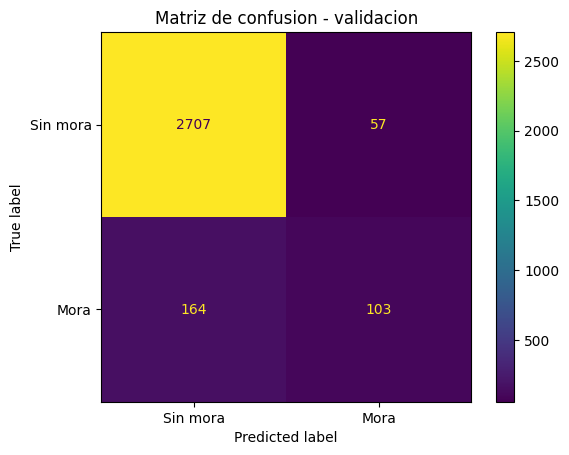

In [21]:
# Guía: ConfusionMatrixDisplay.from_predictions(...) del mejor modelo
ConfusionMatrixDisplay.from_predictions(
    y_val,
    logistic.predict(X_val),
    display_labels=["Sin mora", "Mora"],
)

plt.title("Matriz de confusion - validacion")
plt.show()

**Interpretación:**

> Guía: qué significa cada celda (TP, TN, FP, FN) para el comité de créditos.

### 9.4 Efecto del umbral de decisión

In [18]:
# Guía: con predict_proba, evaluar varios umbrales (p. ej. 0.10, 0.20, 0.30, 0.50)
# Para cada uno: precision, recall, F1 y número de créditos marcados como riesgosos

**Interpretación:**

> Guía: ¿qué umbral conviene si el comité solo deriva a revisión los créditos marcados? ¿Y si los rechazara directamente?

### 9.5 Curvas Precision–Recall y ROC

In [19]:
# Guía: precision_recall_curve y roc_curve de ambos modelos en el mismo gráfico

**Interpretación:**

### 9.6 Train vs. validation

In [20]:
# Guía: comparar la métrica principal en train y validation para cada modelo

**Interpretación:**

> Guía: ¿algún modelo muestra señales de sobreajuste?

## 10. Estado del proyecto y plan hacia el TF1

**Principales hallazgos:**

**Problemas aún no resueltos:**

**Limitaciones identificadas** (datos, modelo, evaluación):

**Mejoras previstas:**

**Actividades hacia el Trabajo Final:**